

<font face="Times New Roman" size=5>
<div dir=rtl align="center">


<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Nano
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>

<hr/>
<font color="#80a080" size=5>
Course Home Work 2
<br>
</font>
<font size=5>
Instructor: Dr. Ebrahim Pour
<br>
</font>
<font size=4>
Spring 2026
<br>
</font>





> **Student**:
>
> Kian Mamdouhi: 400108066

# **Section1:** Reading first 4000 datas



In [2]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
import time
import math
#  try to reading .mat type file by converting to python

path =  "C:/term10\ML/tamrin\HW2\Data_hoda_full.mat"                   # save path of the data file
data = loadmat(path)               # loadmat function help to reading matlab file in python interpreter

# Names of variables
print(data.keys()) # given file has several forms of information like header, version ,... . but for my work i use data(image of handwrited number) and label(name of each data and exact number that wrote)


dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])


In [3]:
#  defining the data and its lable of each sample on whole set of datas
all_image= data['Data']        # give Data of whole set and save in all-image
all_label = data['labels']     # . .    labels       ....          ..      all_label
# selected first  4000images
N = 4000
raw_images = np.empty(N, dtype=object) # make empty array that has 4000 entrys
labels = np.empty(N, dtype=np.int32)
heights = []     #define empty array for heights and widths in each image we have this as (heights, widths)
widths = []


# this loop fill the array with datas and labels
for i in range(N):
    img = all_image[i, 0]
    label = int(all_label[i, 0])
    # in hw1 we convert image to grayscale for anylising simpler than RGB so i do it again because the color of images isnt important issue
    from PIL import Image
    gray = Image.fromarray(img).convert('L')
    gray=np.array(gray)
    raw_images[i] = gray
    labels[i] = label
    h,w = gray.shape
    heights.append(h)# fill hisghts and witdths of each entry for loop from sample 1 till4000
    widths.append(w)
# max help to find maximum of data
max_height = max(heights)
max_width = max(widths)

print(f"h_max = {max_height}, w_max = {max_width}")



h_max = 54, w_max = 45


# **Section2:** centralizing

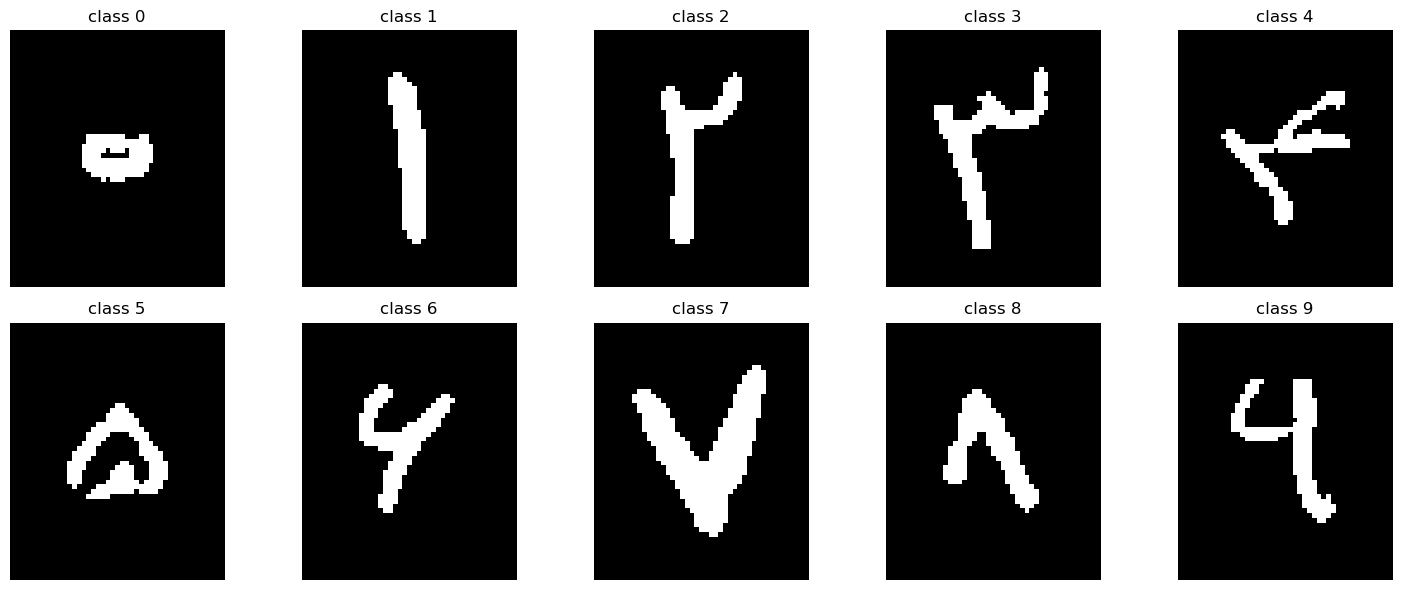

Representative indices: [np.int64(2), np.int64(62), np.int64(3), np.int64(12), np.int64(22), np.int64(1), np.int64(0), np.int64(4), np.int64(28), np.int64(19)]


In [4]:
# in this section we resize all images and map them  on the bigest image to compare them
import numpy as np
images = np.zeros((4000,max_height,max_width), dtype=np.uint8)  #make array of zero matrix with hmax_wmax size

for i, gray in enumerate(raw_images):

    h, w = gray.shape

    y = (max_height - h) // 2
    x = (max_width - w) // 2
    images[i, y:y+h, x:x+w] = gray
#  now the number in each item be in center of picture
# its time to fact check cod
#show the one sample of each number from 0 to 9

def display_class_samples(images, labels, num_classes=10, per_row=5):

    indices = []

    for c in range(num_classes):     # search in images and find first lable 0 and save it in indecies than search for 1 one .....

        class_idx = np.where(labels == c)[0]

        if len(class_idx) == 0:
            indices.append(None)
        else:
            indices.append(class_idx[0])

    rows = math.ceil(num_classes / per_row)

    plt.figure(figsize=(per_row*3, rows*3))

    for i, idx in enumerate(indices):

        if idx is None:
            continue

        plt.subplot(rows, per_row, i+1)
        plt.imshow(images[idx], cmap='gray')
        plt.title(f"class {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return indices



rep_indices = display_class_samples(images, labels)
print("Representative indices:", rep_indices)
# every images are in grayscal mode and centrilized for reduce upcoming errors


# **Section3:** Extracion

**zoning:**
- A feature extraction method that divides an image into a grid of smaller regions (zones) and computes a simple statistic (such as pixel density) from each zone to form a feature vector.

In [5]:
def zoning_features(image, zones=6):     #zones: number of divisions per dimension (e.g., 4 → 4x4 = 16 zones)

    h, w = image.shape
    zone_h = h // zones
    zone_w = w // zones

    features = []    # block size is zone_h*zone_w

    for i in range(zones):
        for j in range(zones):
            zone = image[i*zone_h:(i+1)*zone_h, j*zone_w:(j+1)*zone_w]

            # count foreground pixels (white > 0)
            feature = np.sum(zone > 0)

            features.append(feature)

    return np.array(features)

**Histogram:**
-  A feature extraction technique that counts the number of foreground pixels in each row or column of an image, creating horizontal and vertical profiles that describe the shape of the digit or character.

In [6]:
import numpy as np

def histogram_features(image):

    horizontal = []
    vertical = []

    # Horizontal histogram
    for i in range(image.shape[0]):
        count = 0
        for j in range(image.shape[1]):
            if image[i][j] > 0:
                count += 1
        horizontal.append(count)

    # Vertical histogram
    for j in range(image.shape[1]):
        count = 0
        for i in range(image.shape[0]):
            if image[i][j] > 0:
                count += 1
        vertical.append(count)

    features = horizontal + vertical

    return np.array(features)


In [47]:
# show these two method for extracion
import time
ts = time.time()

X_zoning = np.array([zoning_features(img) for img in images])
X_train_zoning, X_val_zoning = X_zoning[:3000], X_zoning[3000:]


X_hist = np.array([histogram_features(img) for img in images])
X_train_hist, X_val_hist = X_hist[:3000], X_hist[3000:]

te = time.time()

y_train, y_val = labels[:3000], labels[3000:]

print("X_zoning shape:", X_zoning.shape)
print("X_hist shape:", X_hist.shape)
print('Process time:', te-ts)

X_zoning shape: (4000, 36)
X_hist shape: (4000, 99)
Process time: 5.684263706207275


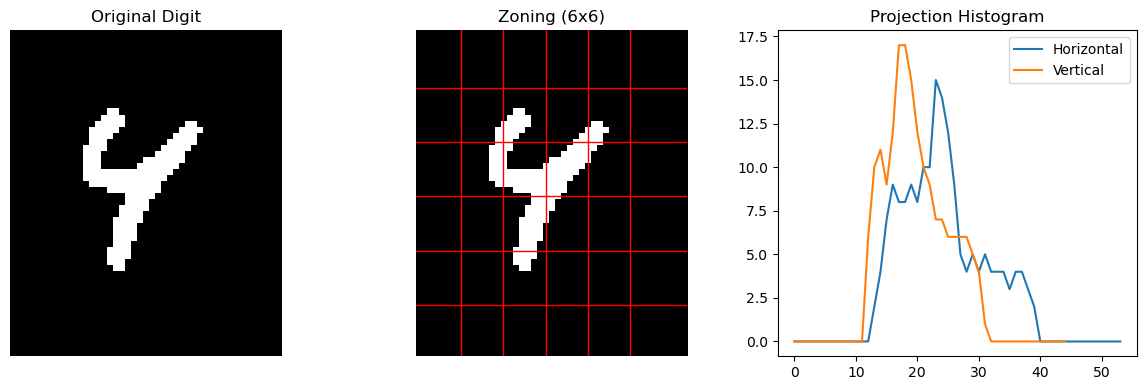

In [89]:
# showing example of each item in one case
import matplotlib.pyplot as plt
import numpy as np


idx = 0
img = images[idx]


z_feat = zoning_features(img)
h_feat = histogram_features(img)

h, w = img.shape
zones = 6
zone_h = h // zones
zone_w = w // zones


horizontal = h_feat[:h]
vertical = h_feat[h:]

plt.figure(figsize=(12,4))


plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Digit")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(img, cmap='gray')

for i in range(1, zones):
    plt.axhline(i * zone_h, color='red', linewidth=1)
    plt.axvline(i * zone_w, color='red', linewidth=1)

plt.title("Zoning (6x6)")
plt.axis("off")

#
plt.subplot(1,3,3)
plt.plot(horizontal, label="Horizontal")
plt.plot(vertical, label="Vertical")
plt.title("Projection Histogram")
plt.legend()

plt.tight_layout()
plt.show()


# **Section4:** Method for clasification

**K-Nearest neighbor:**
- The K-Nearest Neighbor (KNN)  is one of the simplest
classification techniques; yet gives surprisingly high accu
racy. In KNN, there is no training stage. All training samples
must bepresent in the testing phase; and Euclidean distances
between each training sample and the sample to be tested
are calculated. The K training samples that have the smallest
distances to the test sample are found and their classes are
identified. The most frequent class in the selected K training
samples is declared to be the class of the test sample

In [26]:
import numpy as np

 # calculate distance
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))



def knn_predict_single(x_train, y_train, x_test, k):

    distances = []
    ## y_train show the lable(exact number) og item i

    for i in range(len(x_train)):    # len show number of items in x_train
        dist = euclidean_distance(x_train[i], x_test)
        distances.append((dist, y_train[i]))

    #  sorting distance
    distances.sort(key=lambda x: x[0])

    # choosing k neighnor
    neighbors = distances[:k]


    neighbor_labels = [label for (_, label) in neighbors]


    predicted_label = max(set(neighbor_labels), key=neighbor_labels.count)

    return predicted_label
def accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    return correct / len(y_true)

**Parzen window:**
- Parzenwindowestimatestheprobabilitydensityfortheinput
feature space using kernel density estimation technique .
In this technique, every sample in the training set creates a
bump in the feature space with a shape that depends on the
type of kernel used. For a certain test sample, the probability
that it belongs to a certain class is the sum of all the contribu
tions of bumpscreatedbythetraining samplesofthat class at
this test sample. The kernel used in this study is the Gaussian
kernel with a variance chosen to have the best performance
on the validation set. The Parzen window, like KNN, needs
all the training set to be available at test time.
- $$
\hat{p}(x) =
\frac{1}{n h^d}
\sum_{i=1}^{n}
\frac{1}{(2\pi)^{d/2}}
\exp\left(
-\frac{1}{2}
\left( \frac{x - x_i}{h} \right)^T
\left( \frac{x - x_i}{h} \right)
\right)
$$


In [25]:
import numpy as np


# Gaussian kernel (d-dimensional)

def gaussian_kernel(u):
    d = len(u)
    return (1 / ((2 * np.pi) ** (d / 2))) * np.exp(-0.5 * np.dot(u, u))



def parzen_density_for_class(x_train_class, x_test, h):
    n = len(x_train_class)
    d = len(x_test)

    total = 0.0

    for i in range(n):
        u = (x_test - x_train_class[i]) / h
        total += gaussian_kernel(u)

    return total / (n * (h ** d))



def parzen_predict_single(X_train, y_train, x_test, h):
    classes = np.unique(y_train)
    probs = {}

    for c in classes:
        x_train_class = X_train[y_train == c]
        probs[c] = parzen_density_for_class(x_train_class, x_test, h)

    # return class with maximum density
    return max(probs, key=probs.get)



def parzen_predict(X_train, y_train, X_test, h):
    predictions = []

    for i in range(len(X_test)):
        pred = parzen_predict_single(X_train, y_train, X_test[i], h)
        predictions.append(pred)

    return np.array(predictions)


# Accuracy function

def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


**One-vs-One Linear SVM:**
-  A Linear Support Vector Machine (Linear SVM) is a binary classifier that separates two classes using a linear decision boundary, called a hyperplane.

The goal is to find a hyperplane that maximizes the margin, which is the distance between the boundary and the nearest training samples (the support vectors).

Linear Decision Function
For an input vector
𝑥
x
, a linear SVM makes predictions using the function:

$$
f(x)=w
T
 x+b
$$

where:


- w is the weight vector

- b is the bias term The predicted class is determined by the sign of the decision function:

$$
y
^
​
 =sign(w
T
 x+b)
 $$

This gives a natural binary decision:

$$
f(x)>0→y=+1
$$
$$
f(x)<0→y=−1
$$

Because the SVM model is inherently binary, it cannot directly classify multiple classes



In [24]:
import numpy as np


# Train simple linear SVM for binary classification
# labels must be -1 and +1

def train_svm(X_train, y_train, learning_rate=0.001, lambda_param=0.01, epochs=500):
    n_samples, n_features = X_train.shape

    w = np.zeros(n_features)
    b = 0

    for epoch in range(epochs):
        for i in range(n_samples):
            condition = y_train[i] * (np.dot(X_train[i], w) + b) >= 1

            if condition:
                w = w - learning_rate * (2 * lambda_param * w)
            else:
                w = w - learning_rate * (2 * lambda_param * w - y_train[i] * X_train[i])
                b = b - learning_rate * (-y_train[i])

    return w, b


# ------------------------------------------------
# Predict one sample for binary SVM
# ------------------------------------------------
def svm_predict_single(x, w, b):
    value = np.dot(x, w) + b
    if value >= 0:
        return 1
    else:
        return -1


# ------------------------------------------------
# Train OVO classifiers
# ------------------------------------------------
def train_ovo_svm(X_train, y_train, learning_rate=0.001, lambda_param=0.01, epochs=500):
    classes = np.unique(y_train)
    models = []

    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            c1 = classes[i]
            c2 = classes[j]

            mask = (y_train == c1) | (y_train == c2)
            X_pair = X_train[mask]
            y_pair = y_train[mask]

            y_binary = np.where(y_pair == c1, -1, 1)

            w, b = train_svm(X_pair, y_binary, learning_rate, lambda_param, epochs)

            models.append((c1, c2, w, b))

    return models


# ------------------------------------------------
# Predict one sample using OVO voting
# ------------------------------------------------
def ovo_predict_single(x, models):
    votes = {}

    for model in models:
        c1, c2, w, b = model

        if c1 not in votes:
            votes[c1] = 0
        if c2 not in votes:
            votes[c2] = 0

        pred = svm_predict_single(x, w, b)

        if pred == -1:
            votes[c1] += 1
        else:
            votes[c2] += 1

    best_class = max(votes, key=votes.get)
    return best_class


# ------------------------------------------------
# Predict all samples
# ------------------------------------------------
def ovo_predict(X_test, models):
    preds = []

    for i in range(len(X_test)):
        preds.append(ovo_predict_single(X_test[i], models))

    return np.array(preds)


# ------------------------------------------------
# Accuracy
# ------------------------------------------------
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


**Bayes Classifier:**
-Uses probability theory to choose the class with the highest posterior probability
𝑃
(
𝜔
𝑘
∣
𝑥
)
  based on prior probabilities and class‑conditional densities.

In [23]:
import numpy as np


# Compute class statistics (mean and variance)

def compute_class_stats(X_train, y_train):
    classes = np.unique(y_train)
    stats = {}

    for c in classes:
        Xc = X_train[y_train == c]
        mean = Xc.mean(axis=0)
        var  = Xc.var(axis=0) + 1e-6   # avoid division by zero
        prior = len(Xc) / len(X_train)

        stats[c] = (mean, var, prior)

    return stats


# Gaussian likelihood for one class

def gaussian_likelihood(x, mean, var):
    return -0.5 * np.sum(np.log(2 * np.pi * var) + ((x - mean)**2) / var)



# Predict single sample

def bayes_predict_single(x, stats):
    best_class = None
    best_score = -np.inf

    for c, (mean, var, prior) in stats.items():
        score = gaussian_likelihood(x, mean, var) + np.log(prior)
        if score > best_score:
            best_score = score
            best_class = c

    return best_class



# Predict all samples

def bayes_predict(X_test, stats):
    preds = []
    for i in range(len(X_test)):
        preds.append(bayes_predict_single(X_test[i], stats))
    return np.array(preds)


def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


# **Section5:** Expriments

- Find best k for KNN method


Feature mode: zoning
k = 1 accuracy = 0.9
k = 2 accuracy = 0.897
k = 3 accuracy = 0.913
k = 4 accuracy = 0.902
k = 5 accuracy = 0.908
k = 6 accuracy = 0.909
k = 7 accuracy = 0.903
k = 8 accuracy = 0.907
k = 9 accuracy = 0.909
k = 10 accuracy = 0.908
k = 11 accuracy = 0.908
k = 12 accuracy = 0.908
k = 13 accuracy = 0.904
k = 14 accuracy = 0.901
k = 15 accuracy = 0.907
Best k for zoning = 3
Best accuracy = 0.913

Feature mode: histogram
k = 1 accuracy = 0.767
k = 2 accuracy = 0.747
k = 3 accuracy = 0.763
k = 4 accuracy = 0.759
k = 5 accuracy = 0.762
k = 6 accuracy = 0.765
k = 7 accuracy = 0.767
k = 8 accuracy = 0.771
k = 9 accuracy = 0.771
k = 10 accuracy = 0.764
k = 11 accuracy = 0.76
k = 12 accuracy = 0.75
k = 13 accuracy = 0.749
k = 14 accuracy = 0.741
k = 15 accuracy = 0.75
Best k for histogram = 8
Best accuracy = 0.771

Feature mode: combined
k = 1 accuracy = 0.923
k = 2 accuracy = 0.912
k = 3 accuracy = 0.93
k = 4 accuracy = 0.927
k = 5 accuracy = 0.929
k = 6 accuracy = 0.927
k = 

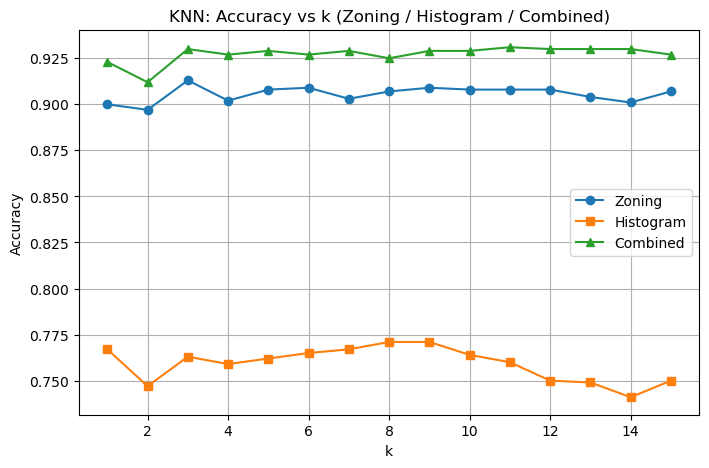

In [27]:
def build_features(images, mode):
    feats = []
    for img in images:
        if mode == "zoning":
            f = zoning_features(img)
        elif mode == "histogram":
            f = histogram_features(img)
        elif mode == "combined":
            f = np.concatenate((zoning_features(img), histogram_features(img)))
        feats.append(f)
    return np.array(feats)


def knn_predict(X_test, X_train, y_train, k):
    predictions = []
    for i in range(len(X_test)):
        pred = knn_predict_single(X_train, y_train, X_test[i], k)
        predictions.append(pred)
    return np.array(predictions)


def find_best_k_curve(X_train, y_train, X_val, y_val, k_list):
    acc_curve = []
    best_k = None
    best_acc = -1

    for k in k_list:
        y_pred = knn_predict(X_val, X_train, y_train, k)
        acc = accuracy(y_val, y_pred)
        acc_curve.append(acc)
        print("k =", k, "accuracy =", acc)

        if acc > best_acc:
            best_acc = acc
            best_k = k

    return best_k, best_acc, acc_curve


def compare_all_features(images_train, y_train, images_val, y_val):

    modes = ["zoning", "histogram", "combined"]
    k_values = list(range(1, 16))

    acc_results = {}

    for mode in modes:
        print("\n=========================")
        print("Feature mode:", mode)
        print("=========================")

        X_train_feat = build_features(images_train, mode)
        X_val_feat   = build_features(images_val, mode)

        best_k, best_acc, acc_curve = find_best_k_curve(
            X_train_feat, y_train,
            X_val_feat, y_val,
            k_values
        )

        acc_results[mode] = acc_curve

        print("Best k for", mode, "=", best_k)
        print("Best accuracy =", best_acc)

    # Plot all three curves (exactly like h plot)

    plt.figure(figsize=(8, 5))

    plt.plot(k_values, acc_results["zoning"],
             marker='o', label="Zoning")

    plt.plot(k_values, acc_results["histogram"],
             marker='s', label="Histogram")

    plt.plot(k_values, acc_results["combined"],
             marker='^', label="Combined")

    plt.xlabel("k")
    plt.ylabel("Accuracy")
    plt.title("KNN: Accuracy vs k (Zoning / Histogram / Combined)")
    plt.legend()
    plt.grid(True)
    plt.show()
compare_all_features(images[:3000], y_train,
                     images[3000:], y_val)



- Find the best h for parzan


=== Parzen: Searching for best h ===

Best h (Zoning):    1.000   Accuracy = 87.30%
Best h (Histogram): 1.000   Accuracy = 76.10%
Best h (Combined):  1.000   Accuracy = 78.20%


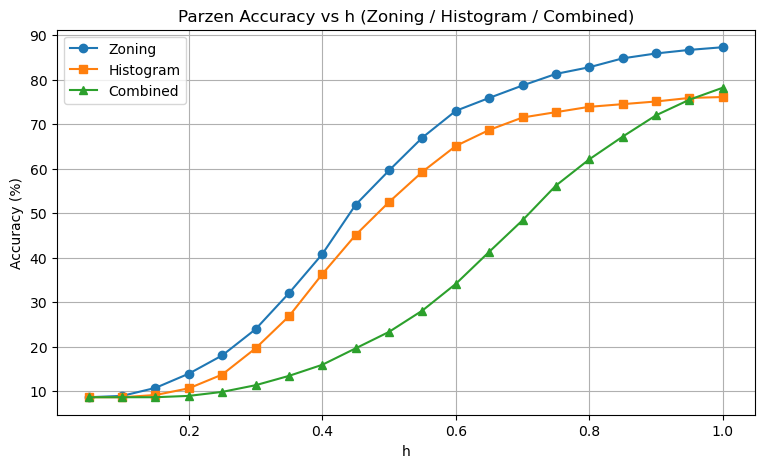

In [96]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt


# Train-Test split  (3000 for training, 1k for testing)

X_train = images[:3000]
y_train = labels[:3000]

X_val   = images[3000:4000]
y_val   = labels[3000:4000]



# Feature Extraction (Zoning, Histogram, Combined)

X_train_zoning = np.array([zoning_features(img) for img in X_train])
X_val_zoning   = np.array([zoning_features(img) for img in X_val])

X_train_hist = np.array([histogram_features(img) for img in X_train])
X_val_hist   = np.array([histogram_features(img) for img in X_val])

X_train_combined = np.hstack((X_train_zoning, X_train_hist))
X_val_combined   = np.hstack((X_val_zoning,  X_val_hist))



# evaluate_model (fixed version)

def evaluate_model(model_func, X_train, y_train, X_val, y_val):
    correct = 0
    total = len(X_val)

    for i in range(total):
        pred = model_func(X_val[i], X_train, y_train)
        if pred == y_val[i]:
            correct += 1

    return correct / total, None




#  h values

h_values = np.linspace(0.05, 1.0, 20)

acc_parzen_zoning   = []
acc_parzen_hist     = []
acc_parzen_combined = []

best_h_zoning = None
best_acc_parzen_zoning = -1

best_h_hist = None
best_acc_parzen_hist = -1

best_h_combined = None
best_acc_parzen_combined = -1


print("\n=== Parzen: Searching for best h ===")



#  ZONING

for h in h_values:
    acc_z, _ = evaluate_model(
        lambda x, Xtr, Ytr, h=h: parzen_predict_single(Xtr, Ytr, x, h),
        X_train_zoning, y_train,
        X_val_zoning,   y_val
    )
    acc_parzen_zoning.append(acc_z)

    if acc_z > best_acc_parzen_zoning:
        best_acc_parzen_zoning = acc_z
        best_h_zoning = h



#  HISTOGRAM

for h in h_values:
    acc_h, _ = evaluate_model(
        lambda x, Xtr, Ytr, h=h: parzen_predict_single(Xtr, Ytr, x, h),
        X_train_hist, y_train,
        X_val_hist,   y_val
    )
    acc_parzen_hist.append(acc_h)

    if acc_h > best_acc_parzen_hist:
        best_acc_parzen_hist = acc_h
        best_h_hist = h


#   COMBINED

for h in h_values:
    acc_c, _ = evaluate_model(
        lambda x, Xtr, Ytr, h=h: parzen_predict_single(Xtr, Ytr, x, h),
        X_train_combined, y_train,
        X_val_combined,   y_val
    )
    acc_parzen_combined.append(acc_c)

    if acc_c > best_acc_parzen_combined:
        best_acc_parzen_combined = acc_c
        best_h_combined = h


# Results

print(f"\nBest h (Zoning):    {best_h_zoning:.3f}   Accuracy = {best_acc_parzen_zoning*100:.2f}%")
print(f"Best h (Histogram): {best_h_hist:.3f}   Accuracy = {best_acc_parzen_hist*100:.2f}%")
print(f"Best h (Combined):  {best_h_combined:.3f}   Accuracy = {best_acc_parzen_combined*100:.2f}%")


# Plot

plt.figure(figsize=(9,5))
plt.plot(h_values, [a*100 for a in acc_parzen_zoning],   marker='o', label='Zoning')
plt.plot(h_values, [a*100 for a in acc_parzen_hist],     marker='s', label='Histogram')
plt.plot(h_values, [a*100 for a in acc_parzen_combined], marker='^', label='Combined')

plt.xlabel('h')
plt.ylabel('Accuracy (%)')
plt.title('Parzen Accuracy vs h (Zoning / Histogram / Combined)')
plt.legend()
plt.grid(True)
plt.show()

- compare accuracy and time of methods


Final Comparison Table

  Classifier    Feature Parameter  Accuracy  Time(sec)
0        KNN     Zoning         3     0.913  23.084697
1        KNN  Histogram         8     0.771  29.309548
2        KNN   Combined         3     0.930  28.817959
3     Parzen     Zoning         1     0.873  20.348396
4     Parzen  Histogram         1     0.761  21.066860
5     Parzen   Combined         1     0.782  22.820841
6      Bayes   Combined         -     0.492   0.128650
7        SVM   Combined         -     0.894  90.226346


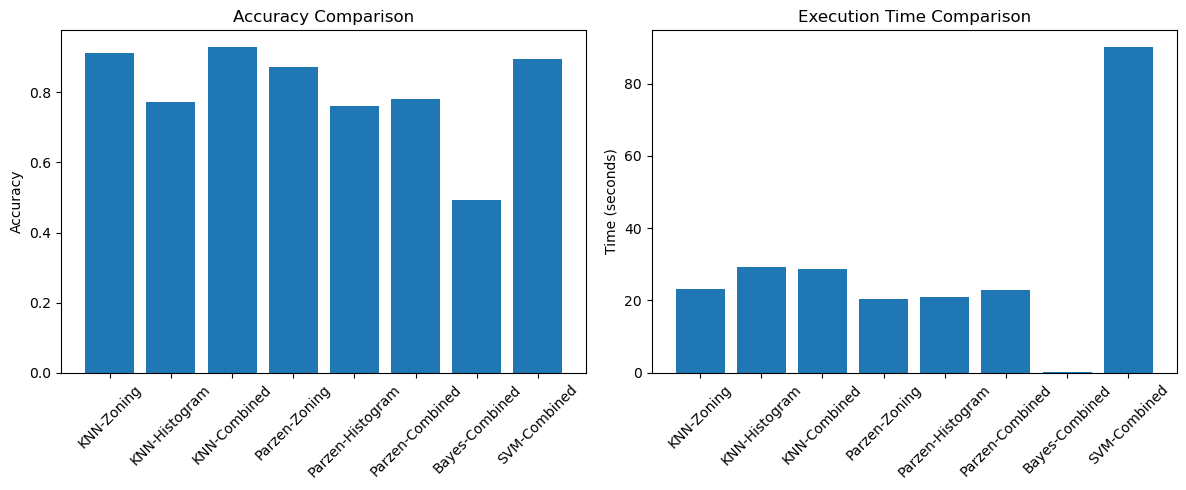

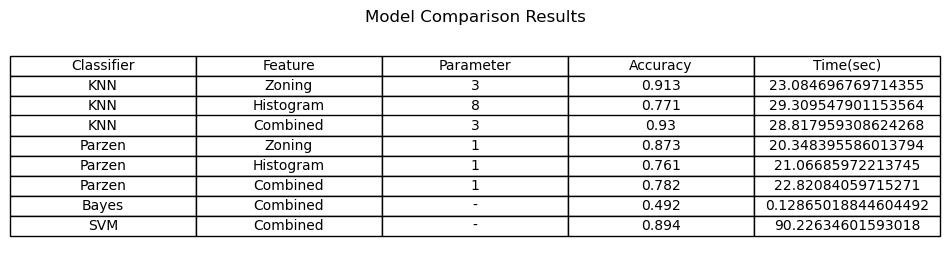

In [31]:
import pandas as pd
import time
import matplotlib.pyplot as plt

results = []


# KNN - Zoning (k = 3)


start = time.time()

y_pred = knn_predict(X_val_zoning, X_train_zoning, y_train, 3)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["KNN","Zoning",3,acc,end-start])



# KNN - Histogram (k = 8)


start = time.time()

y_pred = knn_predict(X_val_hist, X_train_hist, y_train, 8)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["KNN","Histogram",8,acc,end-start])


# KNN - Combined (k = 3)
# Create Combined Features

X_train_combined = np.concatenate((X_train_zoning, X_train_hist), axis=1)
X_val_combined = np.concatenate((X_val_zoning, X_val_hist), axis=1)


start = time.time()

y_pred = knn_predict(X_val_combined, X_train_combined, y_train, 3)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["KNN","Combined",3,acc,end-start])



# Parzen - Zoning (h = 1)


start = time.time()

y_pred = parzen_predict(X_train_zoning, y_train, X_val_zoning, 1)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["Parzen","Zoning",1,acc,end-start])



# Parzen - Histogram (h = 1)


start = time.time()

y_pred = parzen_predict(X_train_hist, y_train, X_val_hist, 1)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["Parzen","Histogram",1,acc,end-start])


# Parzen - Combined (h = 1)


start = time.time()

y_pred = parzen_predict(X_train_combined, y_train, X_val_combined, 1)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["Parzen","Combined",1,acc,end-start])



# Bayes - Combined


start = time.time()

stats = compute_class_stats(X_train_combined, y_train)

y_pred = bayes_predict(X_val_combined, stats)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["Bayes","Combined","-",acc,end-start])

 # SVM - Combined


start = time.time()

models = train_ovo_svm(X_train_combined, y_train)

y_pred = ovo_predict(X_val_combined, models)

end = time.time()

acc = accuracy(y_val, y_pred)

results.append(["SVM","Combined","-",acc,end-start])


# =================================================
# Result Table
# =================================================

df = pd.DataFrame(results,
                  columns=["Classifier","Feature","Parameter","Accuracy","Time(sec)"])

print("\nFinal Comparison Table\n")
print(df)
labels_plot = df["Classifier"] + "-" + df["Feature"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(labels_plot, df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.subplot(1,2,2)
plt.bar(labels_plot, df["Time(sec)"])
plt.xticks(rotation=45)
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")

plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(10,3))

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2,1.2)

plt.title("Model Comparison Results")

plt.savefig("model_comparison_table.png", dpi=300, bbox_inches="tight")

plt.show()



-  Creating Confusion Matrixs for Results

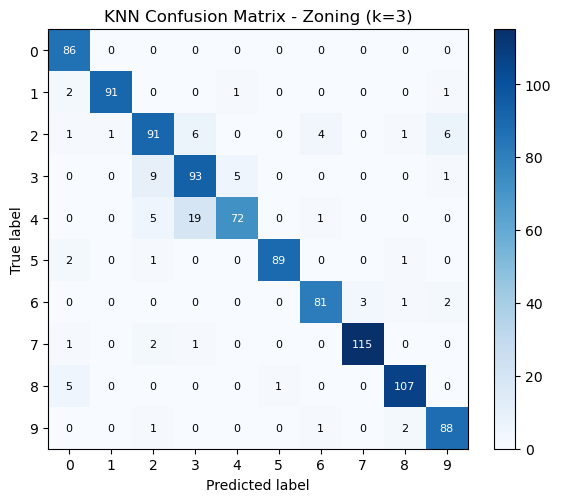

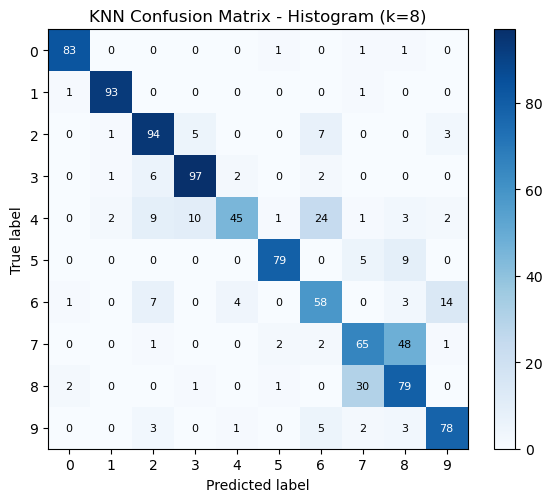

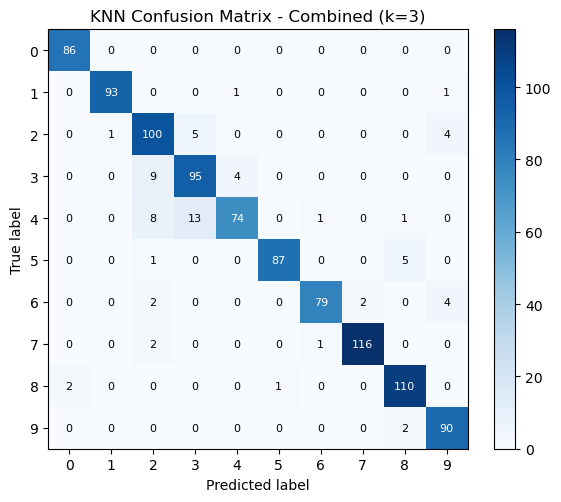

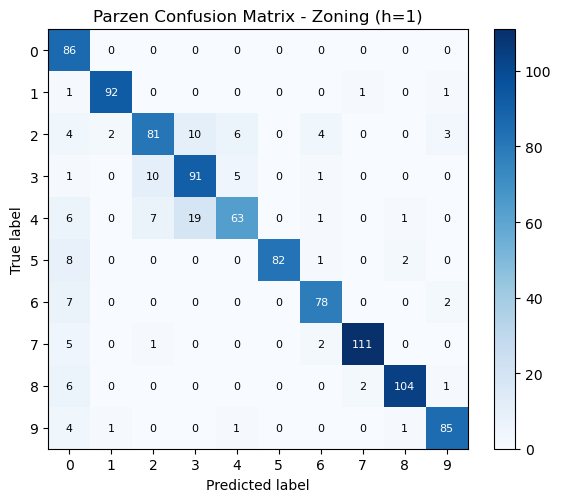

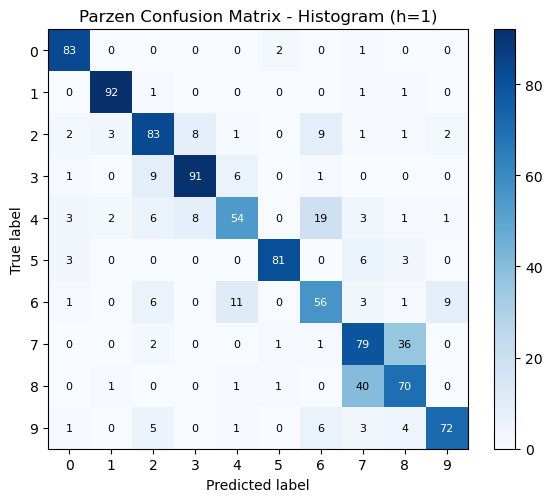

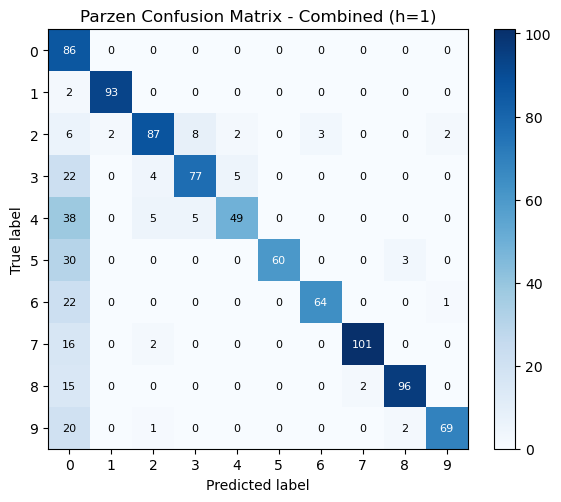

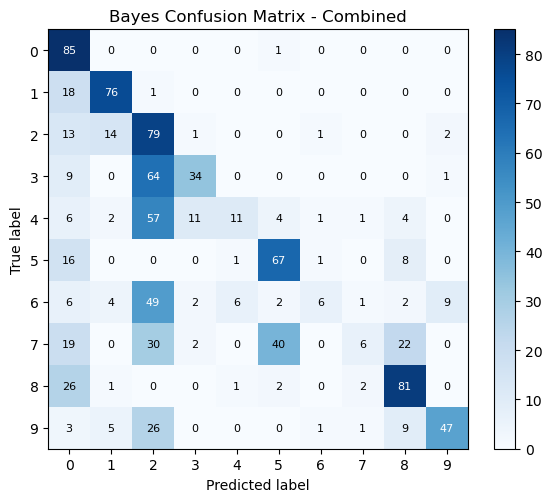

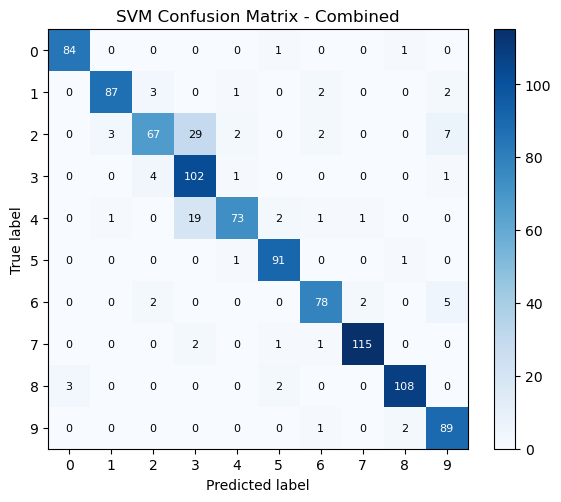

In [34]:
import numpy as np
import matplotlib.pyplot as plt


# Confusion Matrix utilities

def confusion_matrix_manual(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i], y_pred[i]] += 1
    return cm

def plot_confusion_matrix(cm, title, class_names=None):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()

    n = cm.shape[0]
    if class_names is None:
        class_names = [str(i) for i in range(n)]

    plt.xticks(range(n), class_names, rotation=0)
    plt.yticks(range(n), class_names)

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)

    # annotate cells
    for i in range(n):
        for j in range(n):
            val = cm[i, j]
            plt.text(j, i, str(val), ha="center", va="center",
                     color="black" if val < cm.max()/2 else "white",
                     fontsize=8)

    plt.tight_layout()
    plt.show()



# Hyperparameters

k_zoning = 3
k_hist = 8
k_combined = 3

h_best = 1  #   (Zoning/Histogram/Combined)

num_classes = 10
class_names = [str(i) for i in range(num_classes)]



# 1) KNN Confusion Matrices

# Zoning
y_pred = knn_predict(X_val_zoning, X_train_zoning, y_train, k_zoning)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, f"KNN Confusion Matrix - Zoning (k={k_zoning})", class_names)

# Histogram
y_pred = knn_predict(X_val_hist, X_train_hist, y_train, k_hist)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, f"KNN Confusion Matrix - Histogram (k={k_hist})", class_names)

# Combined
y_pred = knn_predict(X_val_combined, X_train_combined, y_train, k_combined)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, f"KNN Confusion Matrix - Combined (k={k_combined})", class_names)



# 2) Parzen Confusion Matrices (h=1)

# Zoning
y_pred = parzen_predict(X_train_zoning, y_train, X_val_zoning, h_best)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, f"Parzen Confusion Matrix - Zoning (h={h_best})", class_names)

# Histogram
y_pred = parzen_predict(X_train_hist, y_train, X_val_hist, h_best)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, f"Parzen Confusion Matrix - Histogram (h={h_best})", class_names)

# Combined
y_pred = parzen_predict(X_train_combined, y_train, X_val_combined, h_best)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, f"Parzen Confusion Matrix - Combined (h={h_best})", class_names)



# 3) Bayes Confusion Matrix (فقط Combined)

stats = compute_class_stats(X_train_combined, y_train)
y_pred = bayes_predict(X_val_combined, stats)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, "Bayes Confusion Matrix - Combined", class_names)

 # 4) SVM Confusion Matrix (فقط Combined)

models = train_ovo_svm(X_train_combined, y_train)
y_pred = ovo_predict(X_val_combined, models)
cm = confusion_matrix_manual(y_val, y_pred, num_classes=num_classes)
plot_confusion_matrix(cm, "SVM Confusion Matrix - Combined", class_names)


 - Effect of noice in recognition


===== Noise Robustness Experiment =====

Noise level: 0
Noise level: 0.05
Noise level: 0.1
Noise level: 0.15
Noise level: 0.2
Noise level: 0.3

Noise experiment finished.


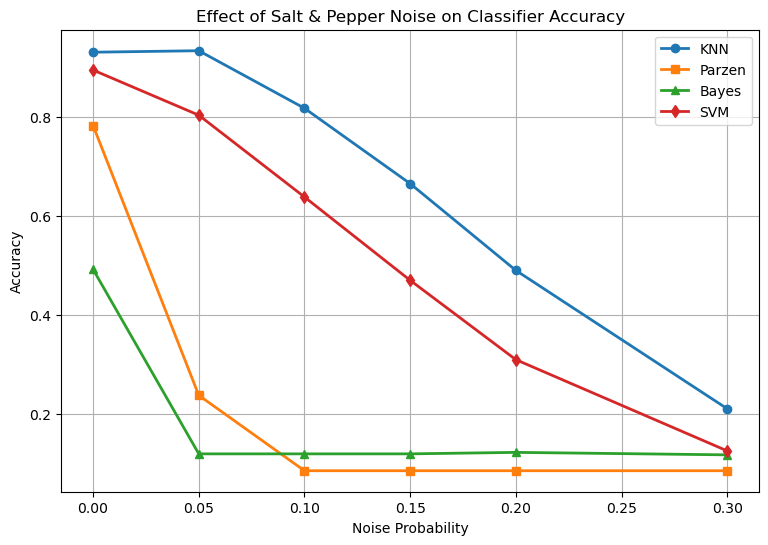


===== Accuracy Table (Noise Robustness) =====

 Noise_Level  KNN_Acc  Parzen_Acc  Bayes_Acc  SVM_Acc
        0.00    0.930       0.782      0.492    0.894
        0.05    0.933       0.238      0.120    0.803
        0.10    0.817       0.086      0.120    0.638
        0.15    0.665       0.086      0.120    0.470
        0.20    0.490       0.086      0.123    0.310
        0.30    0.211       0.086      0.118    0.126


In [38]:

# Section: Investigating the Effect of Noise


import random


# Function: Add Salt & Pepper noise to an image
 --
def add_noise(image, prob):

    noisy = image.copy()

    h, w = noisy.shape

    for i in range(h):
        for j in range(w):

            r = random.random()

            if r < prob:
                noisy[i,j] = 0       # pepper

            elif r > 1 - prob:
                noisy[i,j] = 255     # salt

    return noisy



# Noise levels to test

noise_levels = [0, 0.05, 0.10, 0.15, 0.20, 0.30]

acc_knn = []
acc_parzen = []
acc_bayes = []
acc_svm = []


print("\n===== Noise Robustness Experiment =====\n")



# Loop over noise levels

for p in noise_levels:

    print("Noise level:", p)


    # Add noise to validation images

    noisy_val_images = []

    for img in images[3000:4000]:

        noisy_img = add_noise(img, p)

        noisy_val_images.append(noisy_img)

    noisy_val_images = np.array(noisy_val_images)



    # Feature extraction


    X_val_z_noisy = np.array(
        [zoning_features(img) for img in noisy_val_images]
    )

    X_val_h_noisy = np.array(
        [histogram_features(img) for img in noisy_val_images]
    )

    X_val_c_noisy = np.hstack((X_val_z_noisy, X_val_h_noisy))



    # KNN (best parameters from experiment)


    y_pred_knn = knn_predict(
        X_val_c_noisy,
        X_train_combined,
        y_train,
        3
    )

    acc_knn.append(accuracy(y_val, y_pred_knn))



    # Parzen (best h = 1)


    y_pred_parzen = parzen_predict(
        X_train_combined,
        y_train,
        X_val_c_noisy,
        1
    )

    acc_parzen.append(accuracy(y_val, y_pred_parzen))



    # Bayes


    stats = compute_class_stats(X_train_combined, y_train)

    y_pred_bayes = bayes_predict(
        X_val_c_noisy,
        stats
    )

    acc_bayes.append(accuracy(y_val, y_pred_bayes))



    # SVM


    models = train_ovo_svm(
        X_train_combined,
        y_train
    )

    y_pred_svm = ovo_predict(
        X_val_c_noisy,
        models
    )

    acc_svm.append(accuracy(y_val, y_pred_svm))


print("\nNoise experiment finished.")



# Plot: Accuracy vs Noise


plt.figure(figsize=(9,6))

plt.plot(noise_levels, acc_knn,
         marker='o', linewidth=2, label="KNN")

plt.plot(noise_levels, acc_parzen,
         marker='s', linewidth=2, label="Parzen")

plt.plot(noise_levels, acc_bayes,
         marker='^', linewidth=2, label="Bayes")

plt.plot(noise_levels, acc_svm,
         marker='d', linewidth=2, label="SVM")

plt.xlabel("Noise Probability")

plt.ylabel("Accuracy")

plt.title("Effect of Salt & Pepper Noise on Classifier Accuracy")

plt.legend()

plt.grid(True)

plt.show()
# Table: Accuracy vs Noise Level


import pandas as pd

results_df = pd.DataFrame({
    "Noise_Level": noise_levels,
    "KNN_Acc": acc_knn,
    "Parzen_Acc": acc_parzen,
    "Bayes_Acc": acc_bayes,
    "SVM_Acc": acc_svm
})

print("\n===== Accuracy Table (Noise Robustness) =====\n")
print(results_df.to_string(index=False))


-  Effect of rotaion


===== Rotation Robustness Experiment =====

Rotation angle: 0
Rotation angle: 5
Rotation angle: 10
Rotation angle: 15
Rotation angle: 20
Rotation angle: 30

Rotation experiment finished.


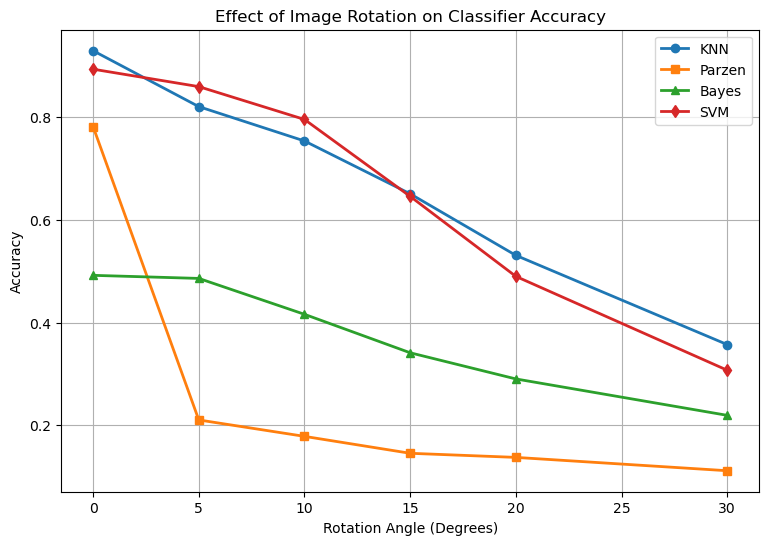

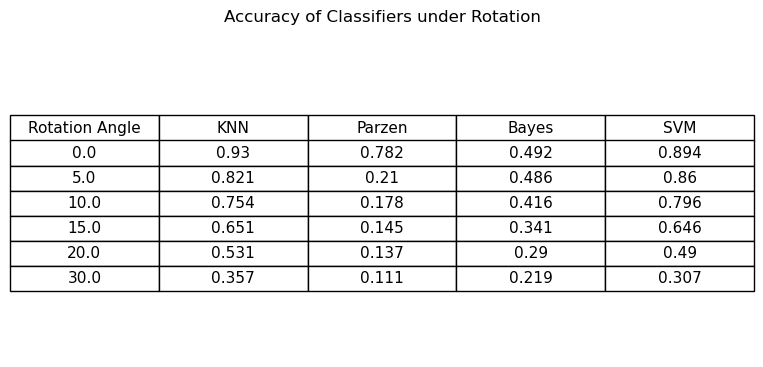

In [39]:

# Section: Investigating the Effect of Rotation

from scipy.ndimage import rotate
import pandas as pd


# Function: Rotate image

def rotate_image(img, angle):

    rotated = rotate(img, angle, reshape=False)

    return rotated



# Rotation angles

rotation_angles = [0, 5, 10, 15, 20, 30]

acc_knn_rot = []
acc_parzen_rot = []
acc_bayes_rot = []
acc_svm_rot = []

print("\n===== Rotation Robustness Experiment =====\n")



# Loop over rotation angles

for angle in rotation_angles:

    print("Rotation angle:", angle)

    rotated_val_images = []

    for img in images[3000:4000]:

        rimg = rotate_image(img, angle)

        rotated_val_images.append(rimg)

    rotated_val_images = np.array(rotated_val_images)



    # Feature Extraction


    X_val_z_rot = np.array(
        [zoning_features(img) for img in rotated_val_images]
    )

    X_val_h_rot = np.array(
        [histogram_features(img) for img in rotated_val_images]
    )

    X_val_c_rot = np.hstack((X_val_z_rot, X_val_h_rot))


    # KNN


    y_pred_knn = knn_predict(
        X_val_c_rot,
        X_train_combined,
        y_train,
        3
    )

    acc_knn_rot.append(accuracy(y_val, y_pred_knn))



    # Parzen


    y_pred_parzen = parzen_predict(
        X_train_combined,
        y_train,
        X_val_c_rot,
        1
    )

    acc_parzen_rot.append(accuracy(y_val, y_pred_parzen))


    # Bayes


    stats = compute_class_stats(X_train_combined, y_train)

    y_pred_bayes = bayes_predict(
        X_val_c_rot,
        stats
    )

    acc_bayes_rot.append(accuracy(y_val, y_pred_bayes))



    # SVM


    models = train_ovo_svm(
        X_train_combined,
        y_train
    )

    y_pred_svm = ovo_predict(
        X_val_c_rot,
        models
    )

    acc_svm_rot.append(accuracy(y_val, y_pred_svm))


print("\nRotation experiment finished.")

# Plot Accuracy vs Rotation


plt.figure(figsize=(9,6))

plt.plot(rotation_angles, acc_knn_rot,
         marker='o', linewidth=2, label="KNN")

plt.plot(rotation_angles, acc_parzen_rot,
         marker='s', linewidth=2, label="Parzen")

plt.plot(rotation_angles, acc_bayes_rot,
         marker='^', linewidth=2, label="Bayes")

plt.plot(rotation_angles, acc_svm_rot,
         marker='d', linewidth=2, label="SVM")

plt.xlabel("Rotation Angle (Degrees)")
plt.ylabel("Accuracy")
plt.title("Effect of Image Rotation on Classifier Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# Graphical Table: Accuracy vs Rotation

import pandas as pd

rotation_results = pd.DataFrame({
    "Rotation Angle": rotation_angles,
    "KNN": acc_knn_rot,
    "Parzen": acc_parzen_rot,
    "Bayes": acc_bayes_rot,
    "SVM": acc_svm_rot
})


fig, ax = plt.subplots(figsize=(8,4))

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=np.round(rotation_results.values, 4),
    colLabels=rotation_results.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title("Accuracy of Classifiers under Rotation", pad=20)

plt.show()


- learning curv


===== Learning Curve Experiment =====

Training size: 500
Training size: 1000
Training size: 1500
Training size: 2000
Training size: 2500
Training size: 3000

Learning curve experiment finished.


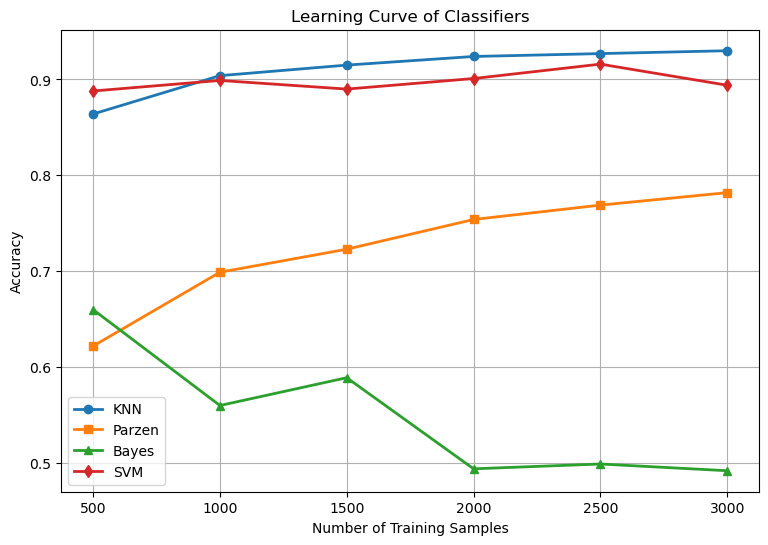

In [40]:

# Experiment: Learning Curve


train_sizes = [500, 1000, 1500, 2000, 2500, 3000]

acc_knn_lc = []
acc_parzen_lc = []
acc_bayes_lc = []
acc_svm_lc = []

print("\n===== Learning Curve Experiment =====\n")

for n in train_sizes:

    print("Training size:", n)

    X_tr = X_train_combined[:n]
    y_tr = y_train[:n]


    # KNN

    y_pred_knn = knn_predict(
        X_val_combined,
        X_tr,
        y_tr,
        3
    )

    acc_knn_lc.append(accuracy(y_val, y_pred_knn))


    # -----------------------
    # Parzen
    # -----------------------
    y_pred_parzen = parzen_predict(
        X_tr,
        y_tr,
        X_val_combined,
        1
    )

    acc_parzen_lc.append(accuracy(y_val, y_pred_parzen))



    # Bayes

    stats = compute_class_stats(X_tr, y_tr)

    y_pred_bayes = bayes_predict(
        X_val_combined,
        stats
    )

    acc_bayes_lc.append(accuracy(y_val, y_pred_bayes))


    # SVM

    models = train_ovo_svm(
        X_tr,
        y_tr
    )

    y_pred_svm = ovo_predict(
        X_val_combined,
        models
    )

    acc_svm_lc.append(accuracy(y_val, y_pred_svm))


print("\nLearning curve experiment finished.")

# Plot Learning Curve


plt.figure(figsize=(9,6))

plt.plot(train_sizes, acc_knn_lc,
         marker='o', linewidth=2, label="KNN")

plt.plot(train_sizes, acc_parzen_lc,
         marker='s', linewidth=2, label="Parzen")

plt.plot(train_sizes, acc_bayes_lc,
         marker='^', linewidth=2, label="Bayes")

plt.plot(train_sizes, acc_svm_lc,
         marker='d', linewidth=2, label="SVM")

plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")

plt.title("Learning Curve of Classifiers")

plt.legend()
plt.grid(True)

plt.show()
